# Imports

In [24]:
import os, sys
import re
import json
import math
import random
from pathlib import Path

ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
if ROOT not in sys.path:
    sys.path.append(ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from modules.eml_loader import EmlLoader
from data.constants import SUSPICIOUS_TLDS, BENIGN_ROOTS
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    precision_recall_curve,
    ConfusionMatrixDisplay,
)

from sklearn.linear_model import LogisticRegression

# XGBoost + LightGBM (make sure they are installed)
try:
    from xgboost import XGBClassifier
except ImportError as e:
    raise ImportError(
        "xgboost is not installed. Install with `pip install xgboost`"
    ) from e

try:
    from lightgbm import LGBMClassifier
except ImportError as e:
    raise ImportError(
        "lightgbm is not installed. Install with `pip install lightgbm`"
    ) from e

# SHAP explanations
try:
    import shap
    HAS_SHAP = True
except Exception:
    HAS_SHAP = False
    print("[WARN] SHAP not installed; skipping SHAP plots.")


# 0. Config
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Adjust this path if needed
DATA_PATH = "../../datasets/processed/final_combined.csv"

# Column names in your CSV
HEADER_COL = "headers_raw"
LABEL_COL  = "label"

OUT_DIR = "header_stage4_models"
os.makedirs(OUT_DIR, exist_ok=True)

[WARN] SHAP not installed; skipping SHAP plots.


# Load Your Dataset

In [25]:
df = pd.read_csv(DATA_PATH)
eml_loader = EmlLoader(config={}, bypass=True)

if HEADER_COL not in df.columns:
    raise ValueError(f"{HEADER_COL} column not found in {DATA_PATH}")

if LABEL_COL not in df.columns:
    raise ValueError(f"{LABEL_COL} column not found in {DATA_PATH}")

# Keep only rows that actually have headers + labels
df = df[df[HEADER_COL].notna()].copy()
df = df[df[LABEL_COL].notna()].copy()

df[LABEL_COL] = df[LABEL_COL].astype(int)
df = df.sample(frac=1, random_state=SEED).reset_index(drop=True)

print("[INFO] Dataset loaded for headers:")
print(df[LABEL_COL].value_counts())
print("Total rows:", len(df))

df.head()

[INFO] Dataset loaded for headers:
label
1    52603
0    30334
Name: count, dtype: int64
Total rows: 82937


/tmp/ipykernel_225600/895354503.py:1: DtypeWarning: Columns (3,4,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(DATA_PATH)


,id,subject,body_text,attachment_text,headers_raw,from_email,to_email,reply_to_email,date,urls,header_from_reply_mismatch,header_domain_mismatch,header_suspicious_tld,header_received_count,header_to_anomaly,header_x_mailer_anomaly,header_date_malformed,label,source
0,5d1c1a0f-9cf1-445a-947f-9e783b991fa3,Re: Local Production July 00,"Paul,\n\nAn Amendment to Appendix ""C"" will nee...",NaN,Message-ID: <6759453.1075853764638.JavaMail.ev...,carol_a._miller@dom.com,pleanza@enron.com,NaN,"Fri, 14 Jul 2000 00:37:00 -0700 (PDT)",NaN,0,0,0,0,0,1,0,0,enron
1,f9af3f88-2de1-409e-a7d1-2151c51c1740,Purchase and Sale Agreement,Attached is the latest draft of the Purchase a...,NaN,Message-ID: <30439740.1075850996586.JavaMail.e...,lance.schuler-legal@enron.com,frank.sayre@enron.com,NaN,"Sun, 13 Aug 2000 04:47:00 -0700 (PDT)",NaN,0,0,0,0,0,1,0,0,enron
2,b4fa53dd-90d6-4548-9bb5-545de34a970e,Board Luncheon on December 12th,calendar\n----- Forwarded by Steven J Kean/NA/...,NaN,Message-ID: <29827408.1075846209763.JavaMail.e...,steven.kean@enron.com,maureen.mcvicker@enron.com,NaN,"Fri, 8 Dec 2000 00:19:00 -0800 (PST)",NaN,0,0,0,0,0,1,0,0,enron
3,427d71da-b931-4064-9500-3d50480c8b31,XSS Test Mail,testtest,NaN,From: larry.gleffe@enron.com\nTo: ttaylor@smrh...,larry.gleffe@enron.com,ttaylor@smrh.com,NaN,NaN,NaN,0,0,0,0,0,1,1,1,epvme_phish
4,7b900423-4fcf-49ca-a876-5d5e89db9b9a,RE: Doc's for conference call,Please review and let me know your thoughts on...,NaN,Message-ID: <33554011.1075842749534.JavaMail.e...,gerald.nemec@enron.com,debra.perlingiere@enron.com,NaN,"Thu, 28 Dec 2000 09:30:00 -0800 (PST)",NaN,0,0,0,0,0,1,0,0,enron


# Helper functions

In [26]:
FREEMAIL_DOMAINS = {
    "gmail.com", "yahoo.com", "hotmail.com", "outlook.com",
    "live.com", "aol.com", "icloud.com", "mail.com", "gmx.com",
    "yandex.ru", "yandex.com", "zoho.com", "proton.me", "protonmail.com"
}

HEADER_PRESENCE_LIST = [
    "from", "to", "subject", "date", "reply-to", "sender", "return-path",
    "received", "message-id", "authentication-results", "dkim-signature",
    "domainkey-signature", "received-spf", "x-spam-flag", "x-spam-status",
    "x-originating-ip", "x-mailer", "mime-version", "content-type",
    "content-transfer-encoding", "list-id", "list-unsubscribe", "x-priority",
]

def _extract_first_header_line(headers: str, field: str) -> str:
    """
    Rough extraction of first occurrence of 'Field:' (case-insensitive).
    Does NOT fully unfold multi-line values, but works reasonably for addresses.
    """
    pattern = re.compile(rf"^{re.escape(field)}\s*:(.*)$", re.IGNORECASE | re.MULTILINE)
    m = pattern.search(headers)
    if not m:
        return ""
    # Include continuation lines that start with whitespace
    start = m.start()
    end = len(headers)
    for m2 in re.finditer(r"^\S", headers[m.end():], re.MULTILINE):
        end = m.end() + m2.start()
        break
    chunk = headers[start:end]
    # strip "Field:" part
    first_line = chunk.split("\n", 1)[0]
    first_line = re.sub(rf"^{re.escape(field)}\s*:", "", first_line, flags=re.IGNORECASE).strip()
    return first_line


def _extract_email_domain(text: str) -> str:
    """
    Extract domain from first email address found in text.
    """
    if not text:
        return ""
    m = re.search(r"[A-Z0-9._%+-]+@([A-Z0-9.-]+\.[A-Z]{2,})", text, re.IGNORECASE)
    if not m:
        return ""
    domain = m.group(1).lower()
    # strip surrounding brackets or <>
    domain = domain.strip("[]<>")
    return domain


def _tld(domain: str) -> str:
    if not domain or "." not in domain:
        return ""
    return domain.split(".")[-1]


def _is_freemail(domain: str) -> int:
    return int(domain in FREEMAIL_DOMAINS)


def _domain_entropy(domain: str) -> float:
    if not domain:
        return 0.0
    # approximate char distribution entropy
    from collections import Counter
    cnt = Counter(domain)
    total = sum(cnt.values())
    ent = 0.0
    for c in cnt.values():
        p = c / total
        ent -= p * math.log2(p)
    return ent


def _token_stats(headers: str) -> dict:
    """
    Very cheap char/word stats.
    """
    h = headers or ""
    length = len(h)
    lines  = h.count("\n") + 1
    digits = sum(ch.isdigit() for ch in h)
    uppers = sum(ch.isupper() for ch in h)
    lowers = sum(ch.islower() for ch in h)

    specials = sum(ch in "!#$%&'*+,-./:;<=>?@[]^_`{|}~" for ch in h)
    spaces   = sum(ch.isspace() for ch in h)

    words = re.findall(r"\S+", h)
    num_words = len(words)
    avg_word_len = (sum(len(w) for w in words) / num_words) if num_words > 0 else 0.0

    return {
        "len_chars": length,
        "len_lines": lines,
        "count_digits": digits,
        "count_uppers": uppers,
        "count_lowers": lowers,
        "count_specials": specials,
        "count_spaces": spaces,
        "num_words": num_words,
        "avg_word_len": avg_word_len,
        "ratio_digits": digits / length if length > 0 else 0.0,
        "ratio_specials": specials / length if length > 0 else 0.0,
        "ratio_uppers": uppers / length if length > 0 else 0.0,
    }


def _spf_dkim_dmarc_features(headers: str) -> dict:
    h = headers.lower()

    # SPF
    spf_res = re.search(r"spf=(pass|fail|softfail|neutral|none|temperror|permerror)", h)
    spf_val = spf_res.group(1) if spf_res else "none"

    # DKIM
    dkim_res = re.search(r"dkim=(pass|fail|none|temperror|permerror)", h)
    dkim_val = dkim_res.group(1) if dkim_res else "none"

    # DMARC
    dmarc_res = re.search(r"dmarc=(pass|fail|none|temperror|permerror)", h)
    dmarc_val = dmarc_res.group(1) if dmarc_res else "none"

    feats = {}
    for val in ["pass", "fail", "softfail", "neutral", "none", "temperror", "permerror"]:
        feats[f"spf_{val}"]   = int(spf_val == val)
        feats[f"dkim_{val}"]  = int(dkim_val == val)
        feats[f"dmarc_{val}"] = int(dmarc_val == val)

    return feats


def _received_features(headers: str) -> dict:
    h = headers
    h_lower = h.lower()

    # naive count of hops
    received_lines = re.findall(r"^received:", h_lower, flags=re.MULTILINE)
    num_received = len(received_lines)

    # private IP in Received (10.x, 192.168.x, 172.16-31.x)
    private_ip_pattern = r"(10\.\d{1,3}\.\d{1,3}\.\d{1,3})|(192\.168\.\d{1,3}\.\d{1,3})|(172\.(1[6-9]|2[0-9]|3[0-1])\.\d{1,3}\.\d{1,3})"
    has_private_ip = int(bool(re.search(private_ip_pattern, h)))

    # suspicious non-RFC1918 IP patterns (only digits + dots, but not private)
    public_ip_pattern = r"\b(?:(?:[0-9]{1,3}\.){3}[0-9]{1,3})\b"
    public_ips = re.findall(public_ip_pattern, h)
    num_public_ips = len(public_ips)

    return {
        "num_received": num_received,
        "has_private_ip_in_received": has_private_ip,
        "num_public_ips": num_public_ips,
    }


def _x_spam_features(headers: str) -> dict:
    h_lower = headers.lower()
    feats = {
        "has_x_spam_flag": 0,
        "x_spam_flag_yes": 0,
        "has_x_spam_status": 0,
        "x_spam_status_yes": 0,
    }
    m_flag = re.search(r"^x-spam-flag:\s*(\S+)", h_lower, flags=re.MULTILINE)
    if m_flag:
        feats["has_x_spam_flag"] = 1
        if "yes" in m_flag.group(1):
            feats["x_spam_flag_yes"] = 1

    m_stat = re.search(r"^x-spam-status:\s*(\S+)", h_lower, flags=re.MULTILINE)
    if m_stat:
        feats["has_x_spam_status"] = 1
        if "yes" in m_stat.group(1):
            feats["x_spam_status_yes"] = 1

    return feats


def _presence_features(headers: str) -> dict:
    h_lower = headers.lower()
    feats = {}
    for name in HEADER_PRESENCE_LIST:
        feats[f"has_{name.replace('-', '_')}"] = int(
            re.search(rf"^{re.escape(name)}\s*:", h_lower, flags=re.MULTILINE) is not None
        )
    return feats


def extract_header_features(headers: str) -> dict:
    """
    Main feature-engineering function.
    Input: raw headers string.
    Output: dict of numeric features.
    Minor upgrade: integrate BENIGN_ROOTS & SUSPICIOUS_TLDS into domain mismatch & TLD analysis.
    """
    if not isinstance(headers, str):
        headers = str(headers or "")

    feats = {}

    # ---------- Existing feature calls ----------
    feats.update(_token_stats(headers))
    feats.update(_presence_features(headers))
    feats.update(_spf_dkim_dmarc_features(headers))
    feats.update(_received_features(headers))
    feats.update(_x_spam_features(headers))

    # ---------- Extract header lines ----------
    from_line       = _extract_first_header_line(headers, "From")
    reply_to_line   = _extract_first_header_line(headers, "Reply-To")
    return_path     = _extract_first_header_line(headers, "Return-Path")
    sender_line     = _extract_first_header_line(headers, "Sender")
    to_line         = _extract_first_header_line(headers, "To")
    message_id_line = _extract_first_header_line(headers, "Message-ID")

    from_dom        = _extract_email_domain(from_line)
    reply_to_dom    = _extract_email_domain(reply_to_line)
    return_path_dom = _extract_email_domain(return_path)
    sender_dom      = _extract_email_domain(sender_line)
    to_dom          = _extract_email_domain(to_line)

    feats["from_has_domain"]         = int(bool(from_dom))
    feats["reply_to_has_domain"]     = int(bool(reply_to_dom))
    feats["return_path_has_domain"]  = int(bool(return_path_dom))
    feats["sender_has_domain"]       = int(bool(sender_dom))
    feats["to_has_domain"]           = int(bool(to_dom))

    # ---------- Freemail / benign domains ----------
    def _is_freemail_or_benign(dom: str) -> int:
        if not dom:
            return 0
        if dom.lower() in BENIGN_ROOTS:
            return 0
        return _is_freemail(dom)

    feats["from_is_freemail"]        = _is_freemail_or_benign(from_dom)
    feats["reply_to_is_freemail"]    = _is_freemail_or_benign(reply_to_dom)
    feats["return_path_is_freemail"] = _is_freemail_or_benign(return_path_dom)
    feats["sender_is_freemail"]      = _is_freemail_or_benign(sender_dom)

    # ---------- Domain lengths and entropy ----------
    feats["from_domain_len"]           = len(from_dom)
    feats["from_domain_entropy"]       = _domain_entropy(from_dom)
    feats["return_path_domain_len"]    = len(return_path_dom)
    feats["return_path_domain_entropy"]= _domain_entropy(return_path_dom)

    # ---------- Domain mismatches, ignore benign roots ----------
    feats["from_reply_mismatch"]       = int(bool(from_dom and reply_to_dom and from_dom != reply_to_dom and from_dom.lower() not in BENIGN_ROOTS))
    feats["from_return_path_mismatch"] = int(bool(from_dom and return_path_dom and from_dom != return_path_dom and from_dom.lower() not in BENIGN_ROOTS))
    feats["from_sender_mismatch"]      = int(bool(from_dom and sender_dom and from_dom != sender_dom and from_dom.lower() not in BENIGN_ROOTS))

    # ---------- TLD analysis ----------
    for prefix, dom in [
        ("from", from_dom),
        ("reply_to", reply_to_dom),
        ("return_path", return_path_dom),
        ("sender", sender_dom),
        ("to", to_dom),
    ]:
        tld = _tld(dom)
        feats[f"{prefix}_tld_len"]        = len(tld)
        feats[f"{prefix}_tld_is_numeric"] = int(tld.isdigit())
        feats[f"{prefix}_tld_is_country"] = int(len(tld) == 2)
        feats[f"{prefix}_tld_suspicious"]= int(tld in SUSPICIOUS_TLDS)  # new feature

    # ---------- MIME-encoded words ----------
    h_lower = headers.lower()
    feats["has_mime_encoded_word"] = int("=?utf-8?" in h_lower or "=?iso-" in h_lower)

    # ---------- Base64-like long chunks ----------
    base64_like = re.findall(r"[A-Za-z0-9+/]{40,}={0,2}", headers)
    feats["num_base64_like_chunks"] = len(base64_like)

    # ---------- List headers ----------
    feats["has_list_headers"] = int("list-id:" in h_lower or "list-unsubscribe:" in h_lower)

    # ---------- X-Originating-IP ----------
    feats["has_x_originating_ip"] = int("x-originating-ip:" in h_lower)

    # ---------- Very crude timezone feature in Date ----------
    date_line = _extract_first_header_line(headers, "Date")
    tz_offset_matches = re.findall(r"([+-]\d{4})", date_line)
    feats["date_has_tz_offset"] = int(bool(tz_offset_matches))

    return feats

# Feature extraction

In [27]:
feature_dicts = df[HEADER_COL].apply(extract_header_features)
features_df = pd.DataFrame(feature_dicts.tolist())

print("[INFO] Feature shape:", features_df.shape)

# Store feature columns order
FEATURE_COLUMNS = sorted(list(features_df.columns))
print("[INFO] Number of features:", len(FEATURE_COLUMNS))

# X matrix, y labels
X = features_df[FEATURE_COLUMNS].astype(float).values
y = df[LABEL_COL].values

[INFO] Feature shape: (82937, 101)
[INFO] Number of features: 101


# Train/Val/Test split

In [28]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.3,
    random_state=SEED,
    stratify=y,
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=SEED,
    stratify=y_temp,
)

print("\n[INFO] Split sizes:")
print("Train:", X_train.shape[0])
print("Val:  ", X_val.shape[0])
print("Test: ", X_test.shape[0])

pos_ratio = y_train.mean()
print(f"[INFO] Training positive ratio (phish=1): {pos_ratio:.4f}")

# class imbalance handling
if pos_ratio > 0:
    scale_pos_weight = (1 - pos_ratio) / pos_ratio
else:
    scale_pos_weight = 1.0
print(f"[INFO] scale_pos_weight ~ {scale_pos_weight:.3f}")


[INFO] Split sizes:
Train: 58055
Val:   12441
Test:  12441
[INFO] Training positive ratio (phish=1): 0.6343
[INFO] scale_pos_weight ~ 0.577


# Train base models: XGB + LGBM

In [29]:
print("\n[INFO] Training XGBoost model...")
xgb_model = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    random_state=SEED,
    n_jobs=-1,
    scale_pos_weight=scale_pos_weight,
)

xgb_model.fit(X_train, y_train)

print("[INFO] Training LightGBM model...")
lgbm_model = LGBMClassifier(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary",
    class_weight="balanced",
    n_jobs=-1,
    random_state=SEED,
)

# LightGBM imbalance handling via scale_pos_weight
lgbm_model.set_params(scale_pos_weight=scale_pos_weight)
lgbm_model.fit(X_train, y_train)


[INFO] Training XGBoost model...
[INFO] Training LightGBM model...
[LightGBM] [Info] Number of positive: 36822, number of negative: 21233
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002868 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3995
[LightGBM] [Info] Number of data points in the train set: 58055, number of used features: 83
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,8
,learning_rate,0.05
,n_estimators,500
,subsample_for_bin,200000
,objective,'binary'
,class_weight,'balanced'
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


# Meta-blender (Logistic Regression)

In [30]:
def get_blend_features(model_xgb, model_lgbm, X_data):
    p_xgb  = model_xgb.predict_proba(X_data)[:, 1]
    p_lgbm = model_lgbm.predict_proba(X_data)[:, 1]
    return np.vstack([p_xgb, p_lgbm]).T  # shape [N, 2]

print("\n[INFO] Building blender (Logistic Regression) on validation set...")
Z_val = get_blend_features(xgb_model, lgbm_model, X_val)

meta_clf = LogisticRegression(
    solver="lbfgs",
    max_iter=1000,
    random_state=SEED,
)
meta_clf.fit(Z_val, y_val)

print("[INFO] Meta coefficients:", meta_clf.coef_, "Intercept:", meta_clf.intercept_)


[INFO] Building blender (Logistic Regression) on validation set...
[INFO] Meta coefficients: [[6.21025897 5.96264189]] Intercept: [-5.64289255]


/home/defalt/.pyenv/versions/venv-3.10.12/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


# Evaluation helpers

In [31]:
def evaluate_probs(y_true, y_probs, threshold=0.5, title_prefix=""):
    y_pred = (y_probs >= threshold).astype(int)

    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="binary", zero_division=0
    )

    print(f"\n[{title_prefix}] threshold={threshold:.3f}")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1       : {f1:.4f}")

    cm = confusion_matrix(y_true, y_pred)
    print("Confusion Matrix:\n", cm)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Legit", "Phish"])
    disp.plot(cmap="Blues", values_format="d")
    plt.title(f"{title_prefix} Confusion Matrix (th={threshold:.2f})")
    plt.show()

    print("\nClassification report:")
    print(classification_report(y_true, y_pred, target_names=["Legit", "Phishing"]))

    # ROC curve
    fpr, tpr, _ = roc_curve(y_true, y_probs)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.3f})")
    plt.plot([0, 1], [0, 1], "k--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{title_prefix} ROC Curve")
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

    # Precision-Recall curve
    precs, recs, _ = precision_recall_curve(y_true, y_probs)
    pr_auc = auc(recs, precs)

    plt.figure(figsize=(6, 5))
    plt.plot(recs, precs, label=f"PR curve (AUC = {pr_auc:.3f})")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"{title_prefix} Precision-Recall Curve")
    plt.legend(loc="lower left")
    plt.grid(True)
    plt.show()

    return {
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
    }

# Evaluate on Test set


[INFO] Evaluating blended model on TEST set...


/home/defalt/.pyenv/versions/venv-3.10.12/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



[Stage-4 Blended Header Model] threshold=0.500
Accuracy : 0.9983
Precision: 0.9984
Recall   : 0.9990
F1       : 0.9987
Confusion Matrix:
 [[4538   13]
 [   8 7882]]


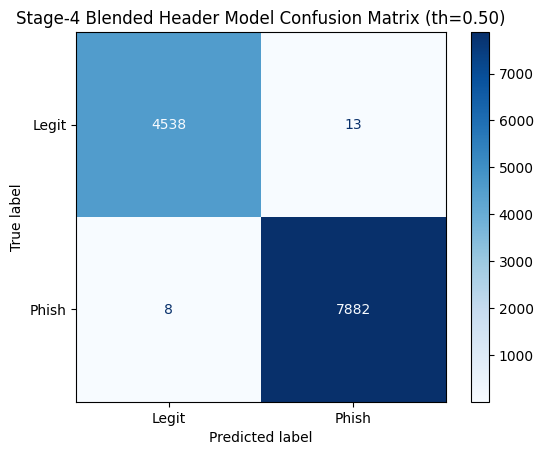


Classification report:
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00      4551
    Phishing       1.00      1.00      1.00      7890

    accuracy                           1.00     12441
   macro avg       1.00      1.00      1.00     12441
weighted avg       1.00      1.00      1.00     12441



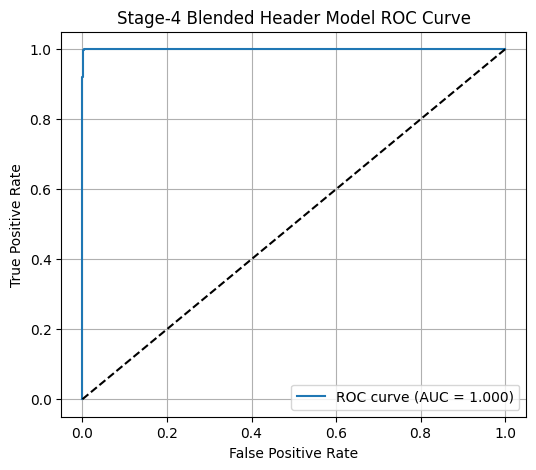

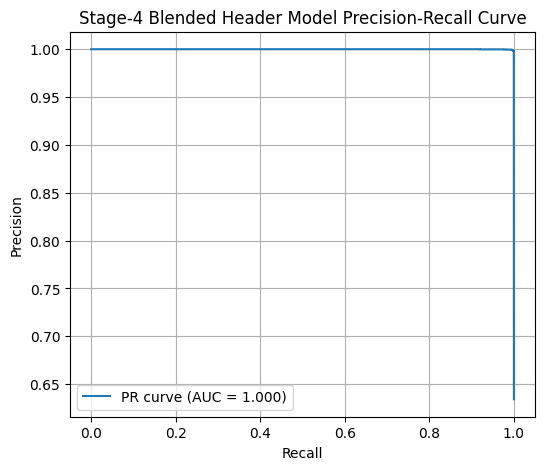


[INFO] Test metrics (threshold=0.5):
{'accuracy': 0.9983120327947914, 'precision': 0.9983533882203927, 'recall': 0.9989860583016477, 'f1': 0.998669623059867, 'roc_auc': 0.9999643805912932, 'pr_auc': 0.9999789663691514}


In [32]:
print("\n[INFO] Evaluating blended model on TEST set...")
Z_test = get_blend_features(xgb_model, lgbm_model, X_test)

# Meta probabilities
test_probs = meta_clf.predict_proba(Z_test)[:, 1]

metrics_default = evaluate_probs(
    y_true=y_test,
    y_probs=test_probs,
    threshold=0.5,
    title_prefix="Stage-4 Blended Header Model",
)

print("\n[INFO] Test metrics (threshold=0.5):")
print(metrics_default)

# Threshold tuning (optional)


[INFO] Tuning threshold on validation set for best F1...
[INFO] Best threshold found: 0.100 (F1=0.9986)

[Stage-4 Blended Header Model (Tuned Threshold)] threshold=0.100
Accuracy : 0.9984
Precision: 0.9980
Recall   : 0.9995
F1       : 0.9987
Confusion Matrix:
 [[4535   16]
 [   4 7886]]


/home/defalt/.pyenv/versions/venv-3.10.12/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


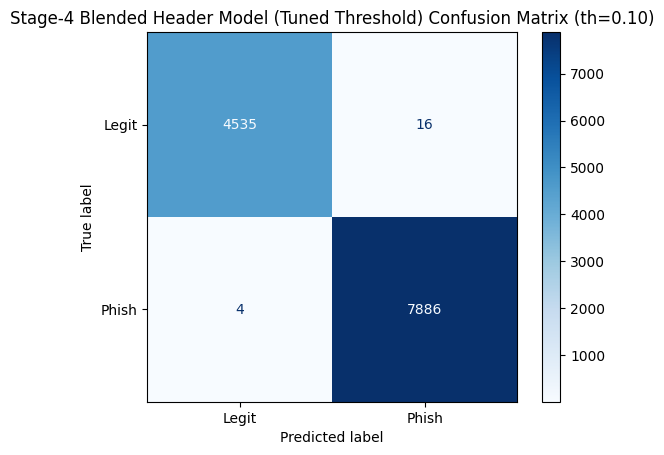


Classification report:
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00      4551
    Phishing       1.00      1.00      1.00      7890

    accuracy                           1.00     12441
   macro avg       1.00      1.00      1.00     12441
weighted avg       1.00      1.00      1.00     12441



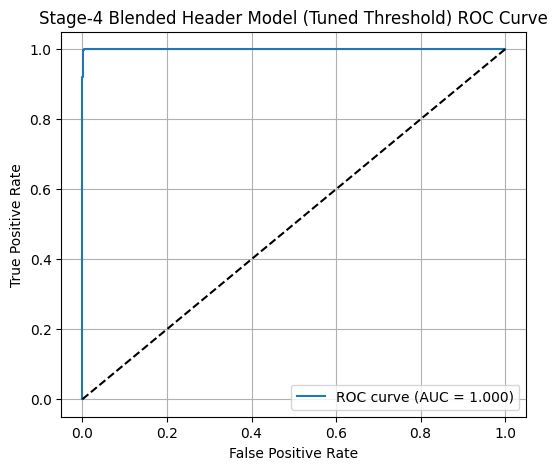

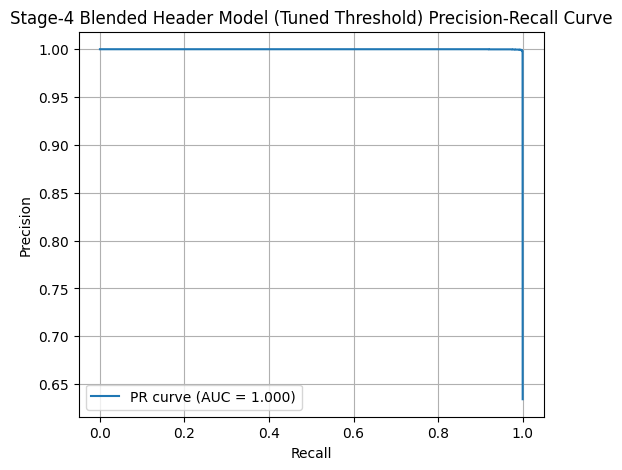


[INFO] Test metrics (tuned threshold):
{'accuracy': 0.9983924121855157, 'precision': 0.9979751961528727, 'recall': 0.9994930291508238, 'f1': 0.9987335359675785, 'roc_auc': 0.9999643805912932, 'pr_auc': 0.9999789663691514}


In [33]:
print("\n[INFO] Tuning threshold on validation set for best F1...")
Z_val_full = get_blend_features(xgb_model, lgbm_model, X_val)
val_probs_full = meta_clf.predict_proba(Z_val_full)[:, 1]

best_th = 0.5
best_f1 = 0.0

for th in np.linspace(0.1, 0.9, 33):  # 0.1 to 0.9 step ~0.025
    preds = (val_probs_full >= th).astype(int)
    _, _, f1, _ = precision_recall_fscore_support(
        y_val, preds, average="binary", zero_division=0
    )
    if f1 > best_f1:
        best_f1 = f1
        best_th = th

print(f"[INFO] Best threshold found: {best_th:.3f} (F1={best_f1:.4f})")

# Evaluate again on test set using tuned threshold
metrics_tuned = evaluate_probs(
    y_true=y_test,
    y_probs=test_probs,
    threshold=best_th,
    title_prefix="Stage-4 Blended Header Model (Tuned Threshold)",
)
print("\n[INFO] Test metrics (tuned threshold):")
print(metrics_tuned)

# Save models + metadata

In [34]:
import joblib

print("\n[INFO] Saving models and metadata...")
joblib.dump(xgb_model, os.path.join(OUT_DIR, "header_xgb_model.pkl"))
joblib.dump(lgbm_model, os.path.join(OUT_DIR, "header_lgbm_model.pkl"))
joblib.dump(meta_clf, os.path.join(OUT_DIR, "header_meta_blender.pkl"))

with open(os.path.join(OUT_DIR, "header_feature_columns.json"), "w", encoding="utf-8") as f:
    json.dump(FEATURE_COLUMNS, f, ensure_ascii=False, indent=2)

with open(os.path.join(OUT_DIR, "header_threshold.json"), "w", encoding="utf-8") as f:
    json.dump({"best_threshold": float(best_th)}, f, indent=2)

print(f"[OK] Models & feature metadata saved to: {OUT_DIR}")


[INFO] Saving models and metadata...
[OK] Models & feature metadata saved to: header_stage4_models


# Feature importance

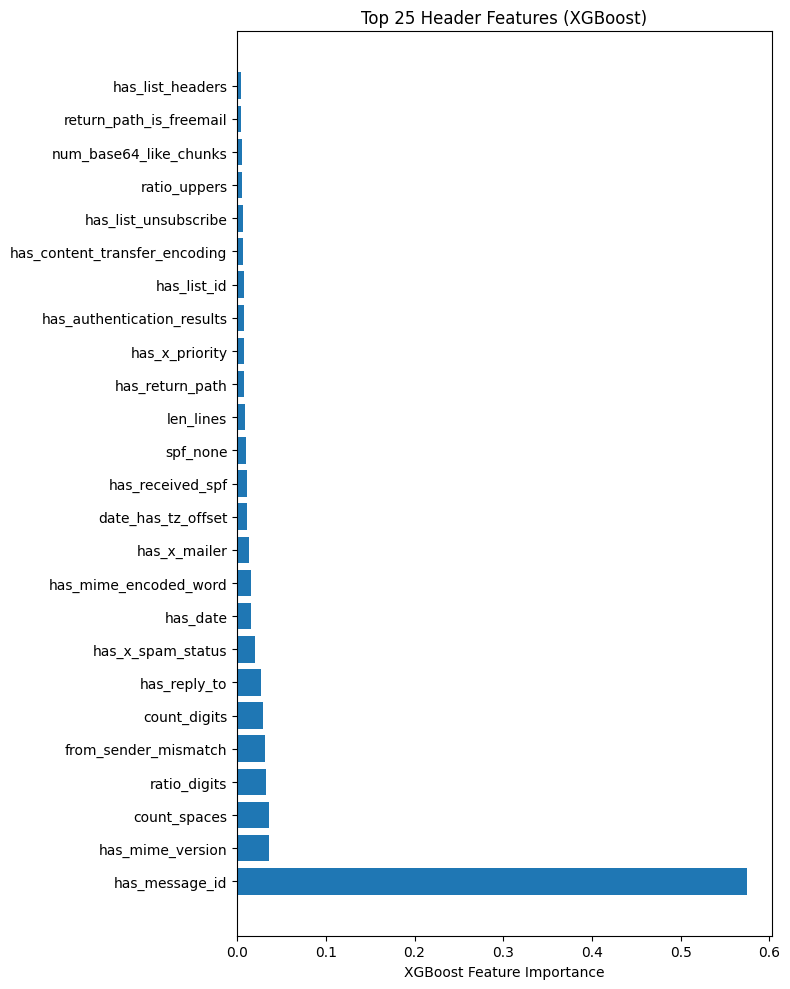

[INFO] SHAP not available, skipping SHAP plots.


In [35]:
# XGBoost feature importance
xgb_importances = xgb_model.feature_importances_
idx_sorted = np.argsort(xgb_importances)[::-1]

top_k = 25
top_idx = idx_sorted[:top_k]
top_feats = [FEATURE_COLUMNS[i] for i in top_idx]
top_vals  = xgb_importances[top_idx]

plt.figure(figsize=(8, 10))
plt.barh(range(len(top_feats))[::-1], top_vals[::-1])
plt.yticks(range(len(top_feats))[::-1], top_feats[::-1])
plt.xlabel("XGBoost Feature Importance")
plt.title("Top 25 Header Features (XGBoost)")
plt.tight_layout()
plt.show()

# Optional SHAP summary for a sample
if HAS_SHAP:
    print("\n[INFO] Computing SHAP values for a sample of test headers (this may take a while)...")
    
    # Get the booster object
    booster = xgb_model.get_booster()

    # Now create SHAP explainer
    explainer = shap.TreeExplainer(booster)
    
    # sample at most 1000 rows for SHAP to keep it fast
    sample_size = min(1000, X_test.shape[0])
    X_sample = X_test[:sample_size]

    shap_values = explainer.shap_values(X_sample)
    shap.summary_plot(shap_values, X_sample, feature_names=FEATURE_COLUMNS, show=True)
else:
    print("[INFO] SHAP not available, skipping SHAP plots.")

# Inference from .eml file

In [60]:
XGB_MODEL_PATH  = "header_stage4_models/header_xgb_model.pkl"
LGB_MODEL_PATH  = "header_stage4_models/header_lgbm_model.pkl"
FEATURE_COLUMNS_PATH = "header_stage4_models/header_feature_columns.json"

# Load models and feature columns once
xgb_model = joblib.load(XGB_MODEL_PATH)
lgb_model = joblib.load(LGB_MODEL_PATH)

with open(FEATURE_COLUMNS_PATH, "r", encoding="utf-8") as f:
    feature_cols = json.load(f)

print("Loaded feature columns:", feature_cols[:10])

def predict_header_eml(eml_path: str, return_proba=True) -> dict:
    """
    Given a raw EML file path, extract headers, compute features, and predict phishing probability.
    Returns a dict with prediction, probability, and optionally feature vector.
    """
    eml_path = Path(eml_path)
    if not eml_path.exists():
        raise FileNotFoundError(f"EML file not found: {eml_path}")

    _, _, headers_raw = eml_loader.separate_header_blocks(eml_path)

    # 2️⃣ Extract features
    feats = extract_header_features(headers_raw)

    # 3️⃣ Build DataFrame for model
    X = pd.DataFrame([feats])
    # Ensure all required features exist
    for col in feature_cols:
        if col not in X.columns:
            X[col] = 0
    X = X[feature_cols]  # order columns as during training

    # 4️⃣ Predict using XGB + LGB ensemble
    proba_xgb = xgb_model.predict_proba(X)[:, 1]
    proba_lgb = lgb_model.predict_proba(X)[:, 1]
    proba = (proba_xgb + proba_lgb) / 2.0  # simple average

    pred = int(proba >= 0.5)

    out = {
        "prediction": "PHISHING" if pred == 1 else "LEGIT",
        "prob_phishing": float(proba[0]),
        "prob_legit": float(1 - proba[0]),
        "features": feats,
    }

    return out

print("\n[INFO] Stage-4 header model ready for inference.")

# Quick manual test (change path to one of your .eml samples)
example_path = "1m."
print(predict_header_eml(example_path))

Loaded feature columns: ['avg_word_len', 'count_digits', 'count_lowers', 'count_spaces', 'count_specials', 'count_uppers', 'date_has_tz_offset', 'dkim_fail', 'dkim_neutral', 'dkim_none']

[INFO] Stage-4 header model ready for inference.
{'prediction': 'LEGIT', 'prob_phishing': 2.4030395549208027e-05, 'prob_legit': 0.9999759696044508, 'features': {'len_chars': 559, 'len_lines': 15, 'count_digits': 49, 'count_uppers': 100, 'count_lowers': 261, 'count_specials': 74, 'count_spaces': 71, 'num_words': 55, 'avg_word_len': 8.872727272727273, 'ratio_digits': 0.08765652951699464, 'ratio_specials': 0.13237924865831843, 'ratio_uppers': 0.17889087656529518, 'has_from': 1, 'has_to': 1, 'has_subject': 1, 'has_date': 1, 'has_reply_to': 0, 'has_sender': 0, 'has_return_path': 0, 'has_received': 0, 'has_message_id': 1, 'has_authentication_results': 0, 'has_dkim_signature': 0, 'has_domainkey_signature': 0, 'has_received_spf': 0, 'has_x_spam_flag': 0, 'has_x_spam_status': 0, 'has_x_originating_ip': 0, 'has

/tmp/ipykernel_225600/4020508110.py:41: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  pred = int(proba >= 0.5)
